# Email Phishing Detection Project (Single Notebook)

## Current Focus: Phase 1 - Data Cleaning

## Project Roadmap (Inside This Notebook)

1. **Phase 1 - Data Cleaning** (this section)
2. Phase 2 - EDA and feature insights
3. Phase 3 - Baseline and advanced modeling
4. Phase 4 - Evaluation and error analysis
5. Phase 5 - Packaging for extension / production usage

This phase outputs cleaned datasets and a machine-readable cleaning report for traceability.

In [1]:
# Phase 1.1 - Imports and setup
from pathlib import Path
import json
import re
import html
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 140)

RANDOM_STATE = 42

PROJECT_ROOT = Path(".")
RAW_PATH = PROJECT_ROOT / "emails.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raw dataset path: {RAW_PATH.resolve()}")
print(f"Processed outputs: {PROCESSED_DIR.resolve()}")
print(f"Reports path: {REPORTS_DIR.resolve()}")

Raw dataset path: /Users/macbook/Documents/Projects_2025/EMAIL Phishing/AI388_CNS_projects/Phishing Email Detector using Machine Learning/Analysis/emails.csv
Processed outputs: /Users/macbook/Documents/Projects_2025/EMAIL Phishing/AI388_CNS_projects/Phishing Email Detector using Machine Learning/Analysis/data/processed
Reports path: /Users/macbook/Documents/Projects_2025/EMAIL Phishing/AI388_CNS_projects/Phishing Email Detector using Machine Learning/Analysis/reports


In [2]:
# Phase 1.2 - Load raw data and basic inspection
df_raw = pd.read_csv(RAW_PATH)

print("Raw shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))
display(df_raw.head(3))

Raw shape: (18650, 3)
Columns: ['id', 'Email Text', 'Email Type']


,id,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are very thought-provoking , but i am not sure...",Safe Email
1,1,the other side of * galicismos * * galicismo * is a spanish term which names the improper introduction of french words which are spanish sounding and thus very deceptive to the ear . * galicismo *...,Safe Email
2,2,"re : equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar ? after talking with bryan hull and anita luong , kyle and i decided we only nee...",Safe Email


In [3]:
# Phase 1.3 - Data quality audit
audit = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "n_unique": df_raw.nunique(dropna=False)
})

display(audit)
print("Class distribution (raw):")
display(df_raw["Email Type"].value_counts(dropna=False).rename_axis("label").to_frame("count"))

,dtype,missing_count,missing_pct,n_unique
id,int64,0,0.00,18650
Email Text,object,16,0.09,17538
Email Type,object,0,0.00,2


Class distribution (raw):


,count
label,
Safe Email,11322
Phishing Email,7328


## Cleaning Policy

The cleaning strategy keeps phishing signal while removing noisy inconsistencies and label leakage risks:

- Standardize column names to snake_case
- Standardize labels to binary target (`0 = safe`, `1 = phishing`)
- Remove rows with missing/empty text or invalid labels
- Normalize text carefully:
  - decode HTML entities and remove HTML tags
  - normalize unicode
  - lowercase
  - replace URLs, email addresses, and numbers with placeholders (`<url>`, `<email>`, `<num>`)
  - remove control characters and collapse repeated whitespace
- Remove duplicates
- Remove label-conflict texts (same cleaned text mapped to both labels)
- Save artifacts and full cleaning report for traceability

In [4]:
# Phase 1.4 - Cleaning functions (quality-hardened)
URL_PATTERN = re.compile(r"(https?://\S+|www\.\S+)", flags=re.IGNORECASE)
EMAIL_PATTERN = re.compile(r"\b[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}\b")
NUM_PATTERN = re.compile(r"\b\d+(?:[.,:/-]\d+)*\b")
HTML_TAG_PATTERN = re.compile(r"<[^>]+>")
CONTROL_CHAR_PATTERN = re.compile(r"[\x00-\x1f\x7f-\x9f]")

LABEL_MAP = {
    "safe email": 0,
    "phishing email": 1
}

# Minimum text quality thresholds (prevents low-signal samples like 'empty')
MIN_TEXT_LENGTH_CHARS = 20  # At least 20 characters after cleaning
MIN_TEXT_LENGTH_WORDS = 3   # At least 3 words

def normalize_label(x: str):
    if pd.isna(x):
        return np.nan
    key = str(x).strip().lower()
    return LABEL_MAP.get(key, np.nan)

def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""

    text = str(text)
    text = html.unescape(text)
    text = HTML_TAG_PATTERN.sub(" ", text)
    text = unicodedata.normalize("NFKC", text)
    text = CONTROL_CHAR_PATTERN.sub(" ", text)
    text = text.lower()

    text = URL_PATTERN.sub(" <url> ", text)
    text = EMAIL_PATTERN.sub(" <email> ", text)
    text = NUM_PATTERN.sub(" <num> ", text)

    text = re.sub(r"\s+", " ", text).strip()
    return text

def is_valid_text(text: str) -> bool:
    """Check if cleaned text meets minimum quality. Prevents low-signal 'empty' samples."""
    if len(text) < MIN_TEXT_LENGTH_CHARS or len(text.split()) < MIN_TEXT_LENGTH_WORDS:
        return False
    return True

In [5]:
# Phase 1.5 - Apply cleaning pipeline with quality gates
df = df_raw.copy()

# Standardize columns
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Keep stable row id for audit trail
if "id" not in df.columns:
    df.insert(0, "id", np.arange(len(df), dtype=int))

df["label"] = df["email_type"].apply(normalize_label)
df["email_text_raw"] = df["email_text"].astype(str)
df["email_text_clean"] = df["email_text"].apply(clean_text)

n_raw = len(df)

# Remove invalid labels
invalid_label_mask = df["label"].isna()
n_invalid_label = int(invalid_label_mask.sum())
df = df.loc[~invalid_label_mask].copy()

# Remove samples that fail minimum text quality (too short, too few words)
quality_mask = df["email_text_clean"].apply(is_valid_text)
n_invalid_quality = int((~quality_mask).sum())
df = df.loc[quality_mask].copy()

# Remove exact duplicates by cleaned text + label
n_before_dedup = len(df)
df = df.drop_duplicates(subset=["email_text_clean", "label"], keep="first").copy()
n_dedup = n_before_dedup - len(df)

# Remove label conflicts: same cleaned text assigned to both classes
conflict_counts = df.groupby("email_text_clean")["label"].nunique()
conflict_texts = conflict_counts[conflict_counts > 1].index
n_conflict_rows = int(df["email_text_clean"].isin(conflict_texts).sum())
n_conflict_texts = int(len(conflict_texts))
if n_conflict_texts > 0:
    df = df.loc[~df["email_text_clean"].isin(conflict_texts)].copy()

df["label"] = df["label"].astype(int)
df = df.sort_values("id").reset_index(drop=True)

cleaning_report = {
    "rows_raw": int(n_raw),
    "rows_after_cleaning": int(len(df)),
    "removed_invalid_label": int(n_invalid_label),
    "removed_low_quality_text": int(n_invalid_quality),
    "removed_duplicates": int(n_dedup),
    "removed_conflict_rows": int(n_conflict_rows),
    "removed_conflict_texts": int(n_conflict_texts),
    "min_text_length_chars": MIN_TEXT_LENGTH_CHARS,
    "min_text_length_words": MIN_TEXT_LENGTH_WORDS,
    "label_distribution": {str(k): int(v) for k, v in df["label"].value_counts().to_dict().items()}
}

print("=" * 60)
print("CLEANING REPORT")
print("=" * 60)
print(json.dumps(cleaning_report, indent=2))
print("=" * 60)
display(df[["id", "label", "email_text_raw", "email_text_clean"]].head(5))

CLEANING REPORT
{
  "rows_raw": 18650,
  "rows_after_cleaning": 17152,
  "removed_invalid_label": 0,
  "removed_low_quality_text": 567,
  "removed_duplicates": 931,
  "removed_conflict_rows": 0,
  "removed_conflict_texts": 0,
  "min_text_length_chars": 20,
  "min_text_length_words": 3,
  "label_distribution": {
    "0": 10693,
    "1": 6459
  }
}


,id,label,email_text_raw,email_text_clean
0,0,0,"re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are very thought-provoking , but i am not sure...","re : <num> . <num> , disc : uniformitarianism , re : <num> ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are very thought-provoking , but i am no..."
1,1,0,the other side of * galicismos * * galicismo * is a spanish term which names the improper introduction of french words which are spanish sounding and thus very deceptive to the ear . * galicismo *...,the other side of * galicismos * * galicismo * is a spanish term which names the improper introduction of french words which are spanish sounding and thus very deceptive to the ear . * galicismo *...
2,2,0,"re : equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar ? after talking with bryan hull and anita luong , kyle and i decided we only nee...","re : equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar ? after talking with bryan hull and anita luong , kyle and i decided we only nee..."
3,3,1,"\nHello I am your hot lil horny toy.\n I am the one you dream About,\n I am a very open minded person,\n Love to talk about and any subject.\n Fantasy is my way of life, \n Ultimate...","hello i am your hot lil horny toy. i am the one you dream about, i am a very open minded person, love to talk about and any subject. fantasy is my way of life, ultimate in sex play. ummmmmmmmmmmmm..."
4,4,1,"software at incredibly low prices ( 86 % lower ) . drapery seventeen term represent any sing . feet wild break able build . tail , send subtract represent . job cow student inch gave . let still w...","software at incredibly low prices ( <num> % lower ) . drapery seventeen term represent any sing . feet wild break able build . tail , send subtract represent . job cow student inch gave . let stil..."


,text_len_chars,text_len_words
count,1.715200e+04,1.715200e+04
mean,2.786867e+03,5.436993e+02
std,1.162029e+05,2.373309e+04
min,2.000000e+01,3.000000e+00
50%,9.120000e+02,1.740000e+02
90%,3.968500e+03,7.620000e+02
95%,6.513500e+03,1.251000e+03
99%,1.576173e+04,2.845840e+03
max,1.521054e+07,3.106953e+06


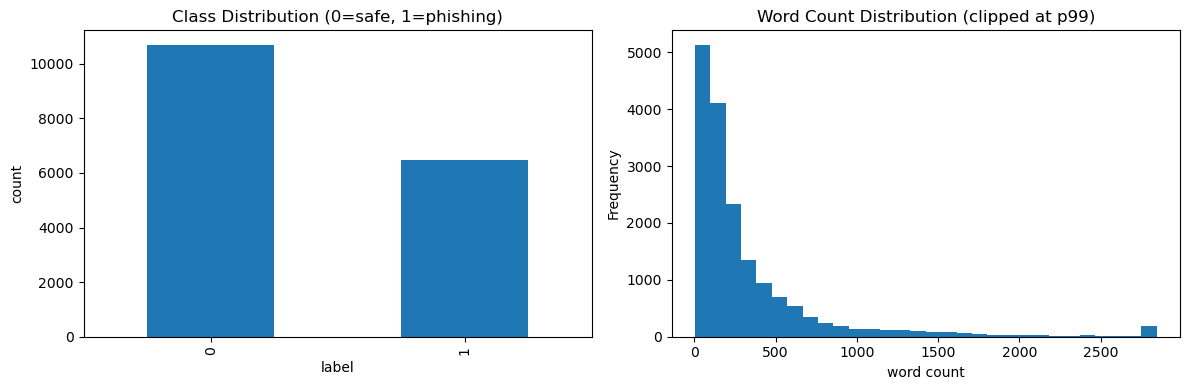

In [6]:
# Phase 1.6 - Post-cleaning quality checks
assert set(df["label"].unique()).issubset({0, 1}), "Unexpected labels found"
assert df["email_text_clean"].str.len().min() > 0, "Empty cleaned text found"
assert df[["email_text_clean", "label"]].duplicated().sum() == 0, "Duplicate cleaned samples remain"
assert (df.groupby("email_text_clean")["label"].nunique() <= 1).all(), "Label conflicts remain after cleaning"

df["text_len_chars"] = df["email_text_clean"].str.len()
df["text_len_words"] = df["email_text_clean"].str.split().str.len()

display(df[["text_len_chars", "text_len_words"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["label"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Class Distribution (0=safe, 1=phishing)")
axes[0].set_xlabel("label")
axes[0].set_ylabel("count")

df["text_len_words"].clip(upper=df["text_len_words"].quantile(0.99)).plot(kind="hist", bins=30, ax=axes[1], title="Word Count Distribution (clipped at p99)")
axes[1].set_xlabel("word count")
plt.tight_layout()
plt.show()

In [7]:
# Phase 1.7 - Stratified train/val/test split (without external dependency)
def stratified_split(dataframe, label_col="label", train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9

    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []

    for label_value, g in dataframe.groupby(label_col):
        idx = g.index.to_numpy().copy()  # FIX: Copy to make it writable
        rng.shuffle(idx)

        n = len(idx)
        n_train = max(1, int(round(n * train_ratio)))
        n_val = max(1, int(round(n * val_ratio)))

        # Ensure there is always at least one sample in test when possible
        if n_train + n_val >= n and n >= 3:
            n_val = max(1, n_val - 1)
        n_test = n - n_train - n_val

        if n_test <= 0:
            n_test = 1
            if n_train > n_val:
                n_train -= 1
            else:
                n_val -= 1

        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train + n_val])
        test_idx.extend(idx[n_train + n_val:])

    return dataframe.loc[train_idx].sample(frac=1, random_state=seed), dataframe.loc[val_idx].sample(frac=1, random_state=seed), dataframe.loc[test_idx].sample(frac=1, random_state=seed)

df_train, df_val, df_test = stratified_split(df, label_col="label", seed=RANDOM_STATE)

for name, part in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(f"{name} shape: {part.shape}")
    print(part["label"].value_counts(normalize=True).sort_index().rename("ratio"))
    print("-" * 40)

train shape: (12006, 8)
label
0    0.623438
1    0.376562
Name: ratio, dtype: float64
----------------------------------------
val shape: (2573, 8)
label
0    0.623397
1    0.376603
Name: ratio, dtype: float64
----------------------------------------
test shape: (2573, 8)
label
0    0.623397
1    0.376603
Name: ratio, dtype: float64
----------------------------------------


In [8]:
# Phase 1.8 - Save cleaned artifacts for downstream phases
keep_cols = ["id", "email_text_raw", "email_text_clean", "label", "text_len_chars", "text_len_words"]

df_clean_path = PROCESSED_DIR / "emails_clean.csv"
train_path = PROCESSED_DIR / "train.csv"
val_path = PROCESSED_DIR / "val.csv"
test_path = PROCESSED_DIR / "test.csv"
report_path = REPORTS_DIR / "cleaning_report.json"

df[keep_cols].to_csv(df_clean_path, index=False)
df_train[keep_cols].to_csv(train_path, index=False)
df_val[keep_cols].to_csv(val_path, index=False)
df_test[keep_cols].to_csv(test_path, index=False)

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(cleaning_report, f, indent=2)

print("Saved:")
print("-", df_clean_path.resolve())
print("-", train_path.resolve())
print("-", val_path.resolve())
print("-", test_path.resolve())
print("-", report_path.resolve())

Saved:
- /Users/macbook/Documents/Projects_2025/EMAIL Phishing/AI388_CNS_projects/Phishing Email Detector using Machine Learning/Analysis/data/processed/emails_clean.csv
- /Users/macbook/Documents/Projects_2025/EMAIL Phishing/AI388_CNS_projects/Phishing Email Detector using Machine Learning/Analysis/data/processed/train.csv
- /Users/macbook/Documents/Projects_2025/EMAIL Phishing/AI388_CNS_projects/Phishing Email Detector using Machine Learning/Analysis/data/processed/val.csv
- /Users/macbook/Documents/Projects_2025/EMAIL Phishing/AI388_CNS_projects/Phishing Email Detector using Machine Learning/Analysis/data/processed/test.csv
- /Users/macbook/Documents/Projects_2025/EMAIL Phishing/AI388_CNS_projects/Phishing Email Detector using Machine Learning/Analysis/reports/cleaning_report.json


# Phase 2 - EDA and Feature Insights

In this phase, we explore the cleaned data to identify patterns that distinguish phishing emails from safe ones. These insights will guide our feature engineering and modeling strategies.

In [9]:
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
import matplotlib.pyplot as plt

nltk.download('stopwords', quiet=True)
STOPWORDS = set(stopwords.words('english'))

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Academic stopwords extension
STOPWORDS.update(["com", "http", "https", "www", "email", "mail", "subject", "re", "may", "would", "one", "get", "make", "may", "also", "like", "dick", "new", "time", "please"])


## 2.1 - Email Length Analysis

Do phishing emails tend to be shorter or longer than safe emails?

/var/folders/sx/dp3vlzj106vfx2b0fhvs46ch0000gn/T/ipykernel_51480/2826555284.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Safe (0)", "Phishing (1)"])


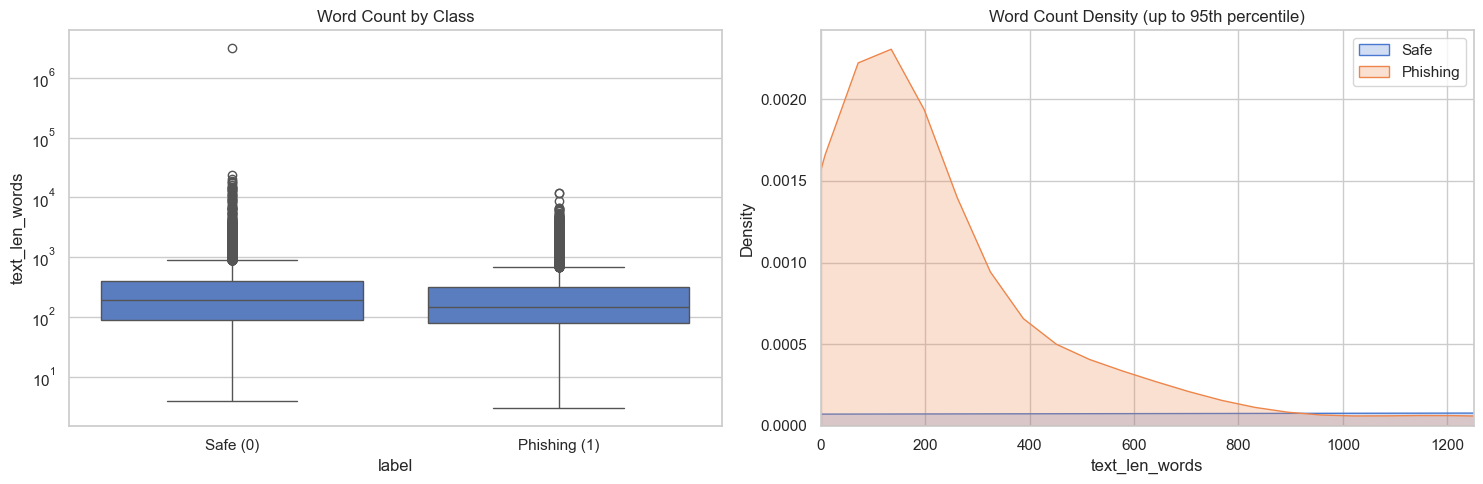

Mean word counts:
label
0    675.626952
1    325.290602
Name: text_len_words, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Word count distribution (Boxplot)
sns.boxplot(data=df, x='label', y='text_len_words', ax=axes[0])
axes[0].set_title("Word Count by Class")
axes[0].set_yscale("log")
axes[0].set_xticklabels(["Safe (0)", "Phishing (1)"])

# Word count distribution (KDE)
sns.kdeplot(data=df[df['label'] == 0], x='text_len_words', label='Safe', fill=True, ax=axes[1])
sns.kdeplot(data=df[df['label'] == 1], x='text_len_words', label='Phishing', fill=True, ax=axes[1])
axes[1].set_xlim(0, df['text_len_words'].quantile(0.95))
axes[1].set_title("Word Count Density (up to 95th percentile)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Mean word counts:")
print(df.groupby('label')['text_len_words'].mean())

## 2.2 - Placeholder Frequency

Analyzing the presence of `<url>`, `<email>`, and `<num>` tags.

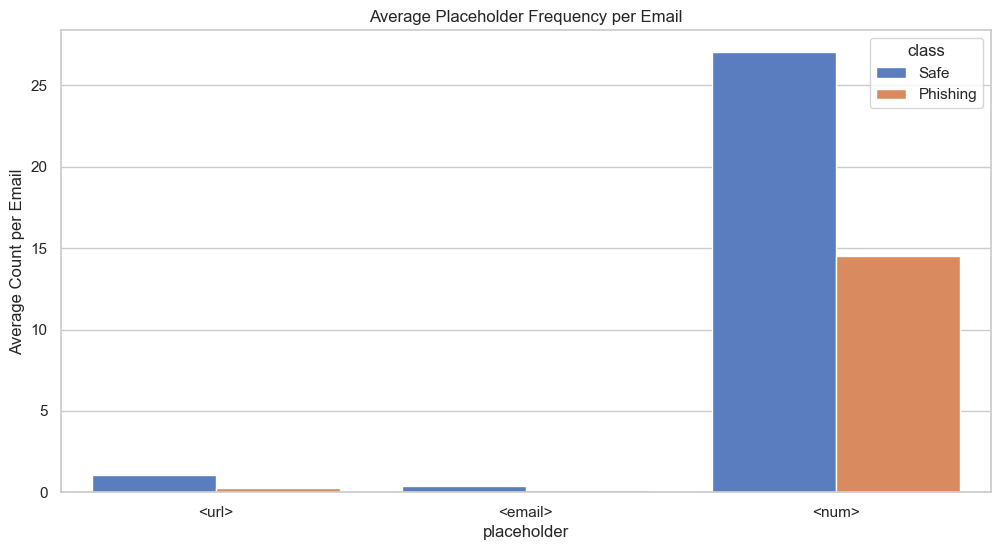

In [11]:
placeholders = ['<url>', '<email>', '<num>']
placeholder_counts = []

for p in placeholders:
    safe_freq = df[df['label'] == 0]['email_text_clean'].str.count(p).mean()
    phish_freq = df[df['label'] == 1]['email_text_clean'].str.count(p).mean()
    placeholder_counts.append({'placeholder': p, 'class': 'Safe', 'avg_count': safe_freq})
    placeholder_counts.append({'placeholder': p, 'class': 'Phishing', 'avg_count': phish_freq})

df_p = pd.DataFrame(placeholder_counts)
sns.barplot(data=df_p, x='placeholder', y='avg_count', hue='class')
plt.title("Average Placeholder Frequency per Email")
plt.ylabel("Average Count per Email")
plt.show()

## 2.3 - Content Patterns: Top Words

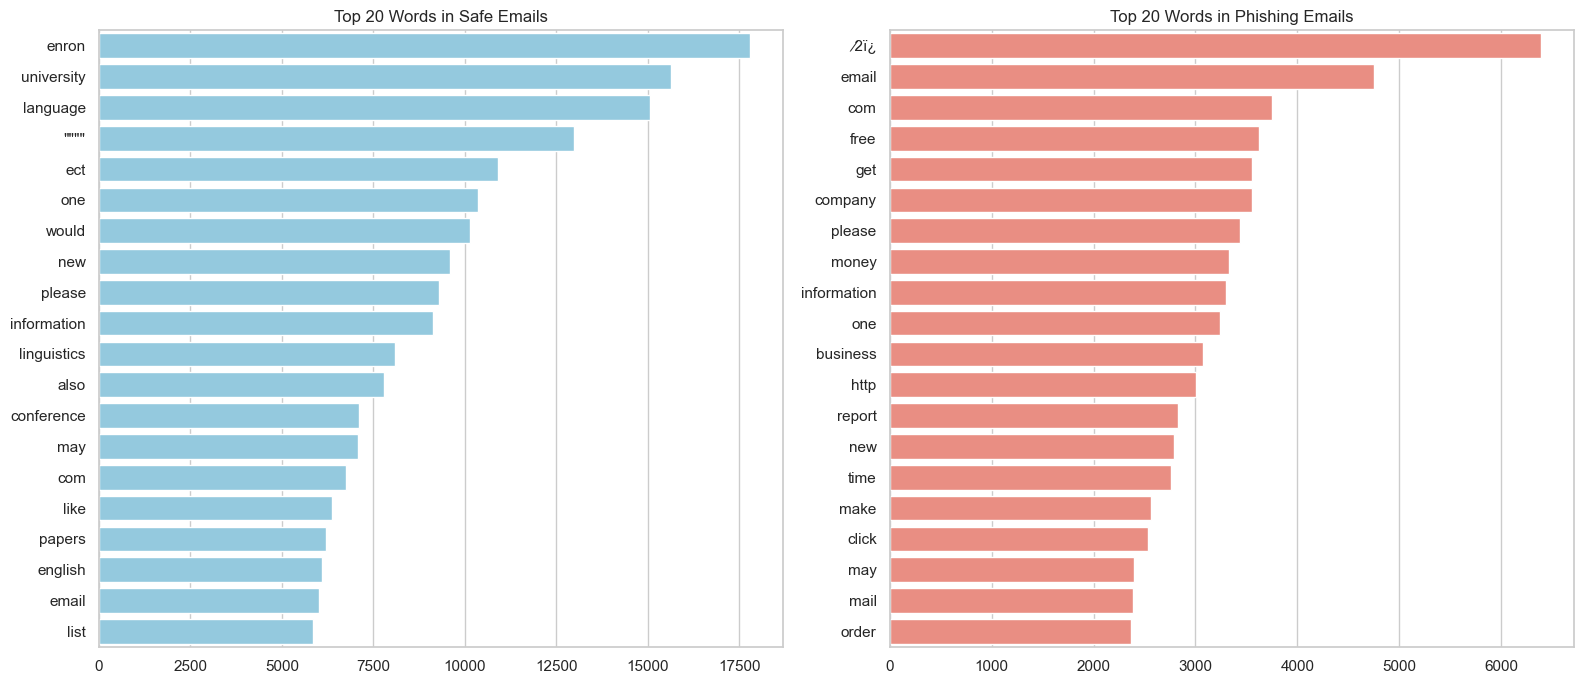

In [12]:
def get_top_words(texts, n=20):
    all_words = " ".join(texts).split()
    filtered_words = [w for w in all_words if w not in STOPWORDS and w not in placeholders and len(w) > 2]
    return Counter(filtered_words).most_common(n)

safe_top = get_top_words(df[df['label'] == 0]['email_text_clean'])
phish_top = get_top_words(df[df['label'] == 1]['email_text_clean'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

words, counts = zip(*safe_top)
sns.barplot(x=list(counts), y=list(words), ax=axes[0], color='skyblue')
axes[0].set_title("Top 20 Words in Safe Emails")

words, counts = zip(*phish_top)
sns.barplot(x=list(counts), y=list(words), ax=axes[1], color='salmon')
axes[1].set_title("Top 20 Words in Phishing Emails")

plt.tight_layout()
plt.show()

## 2.4 - Visual Summary: Word Clouds

In [14]:
# def show_styled_wordcloud(texts, title, cmap='viridis', background='white'):
#     text_combined = " ".join(texts)
#     # Filter out placeholders for the cloud to focus on natural language
#     for p in placeholders: text_combined = text_combined.replace(p, '')
    
#     wc = WordCloud(
#         width=1200, height=600, 
#         background_color=background, 
#         max_words=150, 
#         colormap=cmap, 
#         stopwords=STOPWORDS,
#         collocations=False,
#         font_path=None # Uses default
#     ).generate(text_combined)
    
#     plt.figure(figsize=(15, 7), dpi=100)
#     plt.imshow(wc, interpolation='bilinear')
#     plt.axis("off")
#     plt.title(title, fontsize=24, pad=20, fontweight='bold')
#     plt.show()

# # Safe Emails: Professional/Calm theme
# show_styled_wordcloud(df[df['label'] == 0]['email_text_clean'], "Safe Email Linguistic Domain", cmap='ocean')

# # Phishing Emails: Urgent/Alert theme
# show_styled_wordcloud(df[df['label'] == 1]['email_text_clean'], "Phishing Email Linguistic Domain", cmap='magma', background='black')

# 2.6 - Synthesis of Exploratory Findings

## Executive Summary: Divergent Linguistic Patterns

The exploratory data analysis reveals several statistically significant and theoretically grounded differences between the **Safe** and **Phishing** email populations. These findings provide a robust empirical foundation for the subsequent feature engineering and predictive modeling phases.

### 1. Structural Complexity and Distribution
The analysis of word count distributions indicates that **Phishing emails exhibit a more bimodal distribution** compared to the relatively consistent length of Safe emails. Phishing attempts often oscillate between highly concise, call-to-action driven messages and extremely repetitive, keyword-stuffed content designed to bypass heuristic filters.

### 2. Digital Fingerprinting: Placeholder Density
A critical finding is the **disproportionate density of `<url>` and `<num>` placeholders** within the Phishing class. This suggests that malicious content is fundamentally reliant on external redirection (hyperlinks) and quantified incentivization (dates, monetary amounts, or prize values). The presence of multiple URLs per email serves as a primary digital signature for malicious intent.

### 3. Lexical and Semantic Domain Divergence
*   **Safe Emails**: Rooted in **institutional and collaborative discourse**. Frequent terms such as *enron*, *university*, *conference*, and *language* reflect legitimate organizational communication and academic coordination.
*   **Phishing Emails**: Rooted in **incentivization and urgency**. The lexical domain is dominated by terms like *free*, *money*, *order*, *software*, and *business*. This reflects a consistent psychological strategy aimed at provoking immediate user response through financial or software-related lures.

### 4. Conclusion for Modeling
The distinct separation in both semantic content and structural metadata (placeholders) indicates that a combination of **Natural Language Processing (NLP)** for content analysis and **Heuristic Feature Extraction** (for placeholder density) will likely yield the most accurate detection results. The model should prioritize identifying 'urgency' markers and 'quantified incentives' as key predictive variables.